# Q : 1 
- simulate a fair coin toss 1000 times using numpy and calculate the probability of heads and tails . 
- simulate 6-sided die roll 1000 times and compute probability of each face. 
- visualize the frequency distribution of coin tosses and die rolls using matplotlib/seaborn . 
- verify the law of large numbers by increasing the number of trials and plotting how probabilities converge. 

In [7]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

np.random.seed(42)
coin_trails = 1000
coin = np.random.choice(['Heads','Tails'], size=coin_trails)

# p_heads = np.mean(coin == 'Heads')
# p_tails = np.mean(coin == 'Tails')

heads_count = np.sum(coin == 'Heads')
tails_count = np.sum(coin == 'Tails')

p_heads = heads_count / coin_trails
p_tails = tails_count / coin_trails

print("Heads Count : ",heads_count)
print("Tails Count : ",tails_count)
print("Probability of Heads : ",p_heads)
print("Probability of Tails : ",p_tails)


Heads Count :  490
Tails Count :  510
Probability of Heads :  0.49
Probability of Tails :  0.51


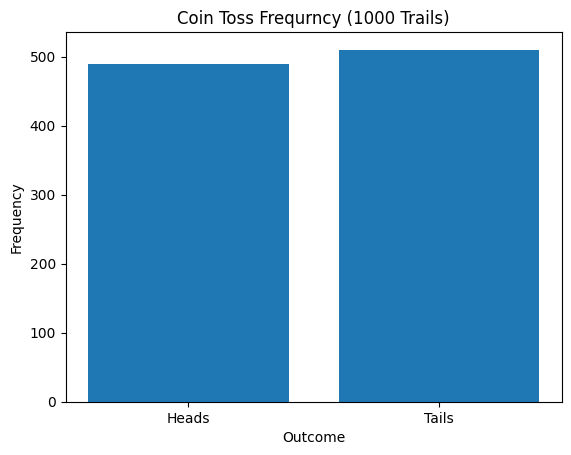

In [2]:
unique, counts = np.unique(coin , return_counts =True)
plt.figure()
plt.bar(unique,counts)
plt.title("Coin Toss Frequrncy (1000 Trails)")
plt.xlabel("Outcome")
plt.ylabel("Frequency")
plt.show()

In [3]:
# total trails
n =1000
die = np.random.randint(1,7,size=n)
print("Die Face Probabilities : ")
for face in range(1,7):
    favorable = np.sum(die == face)
    probability = favorable / n 
    print(f"face {face} : {probability}")

Die Face Probabilities : 
face 1 : 0.178
face 2 : 0.168
face 3 : 0.174
face 4 : 0.133
face 5 : 0.177
face 6 : 0.17


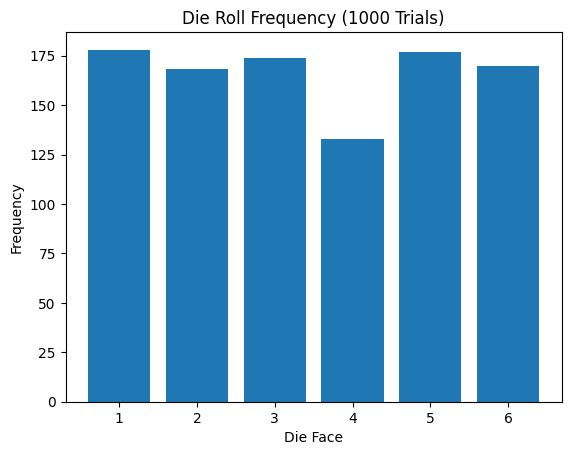

In [4]:
face, counts = np.unique(die,return_counts=True)
plt.figure()
plt.bar(face,counts)
plt.title("Die Roll Frequency (1000 Trials)")
plt.xlabel("Die Face")
plt.ylabel("Frequency")
plt.show()


# Q : 2
- create a sample space for tossing 2 coins and display all possible outcomes using pandas. 
- Count and calculate the probability of specific events (getting exactly one head).
- Use a simulated dataset to demostrate sample space, favourable outcomes, and total outcomes.
- Visualize event probabilities using bar plots 

In [19]:
outcomes = ['HH','HT','TH','TT']
df = pd.DataFrame({
    'Outcome' : outcomes
})
df['Heads_Count'] = [x.count('H') for x in df['Outcome']]
total_outcomes = len(df)

favorable_df = df[df['Heads_Count'] == 1]
favorable_outcomes = len(favorable_df)

probability_one_head =  favorable_outcomes / total_outcomes

print("Favorable Outcomes (Exactly One Head) : \n",favorable_df)
print("Total Number of Outcomes:",total_outcomes)
print("Number of Favorable Outcomes:",favorable_outcomes)
print("Probability of Getting Exactly One Head:",probability_one_head)


Favorable Outcomes (Exactly One Head) : 
   Outcome  Heads_Count
1      HT            1
2      TH            1
Total Number of Outcomes: 4
Number of Favorable Outcomes: 2
Probability of Getting Exactly One Head: 0.5


# Q : 3
- create pandas dataFraem representing a deck of cards or student data (gender,marks,stream)
- calculate the probability of drawing specific items (e.g. a red card, a student scoring > 80 marks.)
- Demonstrate compound events using logical conditions (AND/OR) 

In [82]:
# Student Data DataFrame (Gender, Marks, Stream)

student_data = {
    "Student_ID": [101, 102, 103, 104, 105],
    "Name": ["Amit", "Neha", "Rahul", "Priya", "Karan"],
    "Gender": ["Male", "Female", "Male", "Female", "Male"],
    "Marks": [78, 85, 87, 92, 74],
    "Stream": ["Science", "Commerce", "Science", "Arts", "Commerce"]
}

df_students = pd.DataFrame(student_data)

df_students


,Student_ID,Name,Gender,Marks,Stream
0,101,Amit,Male,78,Science
1,102,Neha,Female,85,Commerce
2,103,Rahul,Male,87,Science
3,104,Priya,Female,92,Arts
4,105,Karan,Male,74,Commerce


In [83]:
total_students = len(df_students)

high_scorers = df_students[df_students["Marks"] > 80]
favorable_students = len(high_scorers)

prob_high_marks = favorable_students / total_students 

print("Total Students:", total_students)
print("Students Scoring > 80:", favorable_students)
print("Probability of Scoring > 80:", prob_high_marks)

Total Students: 5
Students Scoring > 80: 3
Probability of Scoring > 80: 0.6


### Marks > 80 AND Stream = Science

- Event A: Marks > 80
- Event B: Stream = Science
- Required: P(A∩B)

In [84]:
top_science_students = df_students[
    (df_students["Marks"] > 80) &
    (df_students["Stream"] == "Science")
]

favorable_AND = len(top_science_students)
P_AND = favorable_AND / total_students

print("Favorable Outcomes (Marks > 80 AND Science):", favorable_AND)
print("Probability P(A ∩ B):", P_AND)


Favorable Outcomes (Marks > 80 AND Science): 1
Probability P(A ∩ B): 0.2


### Marks > 80 OR Gender = Female

- Event A: Marks > 80
- Event B: Gender = Female
- Required: P(A∪B)

In [85]:
high_or_female = df_students[
    (df_students["Marks"] > 80) |
    (df_students["Gender"] == "Female")
]

favorable_OR = len(high_or_female)
P_OR = favorable_OR / total_students

print("Favorable Outcomes (Marks > 80 OR Female):", favorable_OR)
print("Probability P(A ∪ B):", P_OR)


Favorable Outcomes (Marks > 80 OR Female): 3
Probability P(A ∪ B): 0.6


In [47]:

suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
ranks = ["2","3","4","5","6","7","8","9","10","Jack","Queen","King","Ace"]

deck = [(rank, suit) for suit in suits for rank in ranks]
df_cards = pd.DataFrame(deck, columns=["Rank","Suit"]) 

# print(df_cards.head())
total_cards = len(df_cards)

red_cards = df_cards[df_cards["Suit"].isin(["Hearts","Diamonds"])]
favorable_cards = len(red_cards)

prob_red_card = favorable_cards / total_cards
print("Total Cards : ",total_cards)
print("Red Cards : ",favorable_cards)
print("Probability of Drawing a Red Card : ",prob_red_card)


Total Cards :  52
Red Cards :  26
Probability of Drawing a Red Card :  0.5


In [60]:
# Cards (Compound Events) -- AND Event (Red AND Face Card)

red_face_cards = df_cards[
    (df_cards["Suit"].isin(["Hearts", "Diamonds"])) &
    (df_cards["Rank"].isin(["Jack", "Queen", "King"]))
]
red_face_cards

,Rank,Suit
9,Jack,Hearts
10,Queen,Hearts
11,King,Hearts
22,Jack,Diamonds
23,Queen,Diamonds
24,King,Diamonds


In [69]:
# Event A: Card is Red
A = df_cards[df_cards['Suit'].isin(["Hearts","Diamonds"])]
print("Event A (Red Cards) : ")
# print(A)
Favorable_A = len(A)
total_cards = len(df_cards)
Event_A = Favorable_A / total_cards

print("Favorable Outcome A : ",len(A))
print("Event A : ",Event_A)

Event A (Red Cards) : 
Favorable Outcome A :  26
Event A :  0.5


In [74]:
# Event B: Card is a Face Card (Jack, Queen, King)
B = df_cards[df_cards["Rank"].isin(["Jack","Queen","King"])]
print("Event B (Face Cards)")
# print(B)

Favorable_B = len(B)
total_cards = len(df_cards)
Event_B = Favorable_B / total_cards

print("Favorable Outcome B : ",len(B))
print(f"Event B : {Event_B:.2f}")

Event B (Face Cards)
Favorable Outcome B :  12
Event B : 0.23


In [79]:
A_intersection_B = Event_A * Event_B

print("Event A ∩ B (Red Face Cards):")
print("Probability P(A ∩ B):", P_A_intersection_B)


Event A ∩ B (Red Face Cards):
Probability P(A ∩ B): 0.11538461538461539


In [80]:
A_intersection_B = df_cards[
    (df_cards["Suit"].isin(["Hearts", "Diamonds"])) &
    (df_cards["Rank"].isin(["Jack", "Queen", "King"]))
]

total_cards = len(df_cards)
P_A_intersection_B = len(A_intersection_B) / total_cards

print("Event A ∩ B (Red Face Cards):")
print("Probability P(A ∩ B):", P_A_intersection_B)



Event A ∩ B (Red Face Cards):
Probability P(A ∩ B): 0.11538461538461539


| Event                 | Favorable Outcomes | Probability |
| --------------------- | ------------------ | ----------- |
| A (Red Card)          | 26                 | 0.50        |
| B (Face Card)         | 12                 | 0.23        |
| A ∩ B (Red Face Card) | 6                  | 0.115       |


# Q : 4
- Simulate 1000 coin tosses and compute empirical probability of heads and tails
- compare the result with theoretical probability (0.5 for fair  coin)  and visulize the difference .
- Simulate rolling two dice and compute the probability of getting sum=7 empirically and theoretically .
- plot a line / bar graph computing empirical and theoretical probabilities   for different event  . 

In [89]:
np.random.seed(42)
tosses = np.random.choice(['Head','Tail'],size=1000)

df = pd.DataFrame({"Toss" : tosses})
heads_count = (df["Toss"] == "Head").sum()
tails_count = (df["Toss"] == "Tail").sum()
total_tosses = len(df)

P_heads = heads_count / total_tosses
P_tails = tails_count / total_tosses

print("Total Tosses:", total_tosses)
print("Number of Heads:", heads_count)
print("Number of Tails:", tails_count)
print("Empirical Probability of Heads:", P_heads)
print("Empirical Probability of Tails:", P_tails)

Total Tosses: 1000
Number of Heads: 490
Number of Tails: 510
Empirical Probability of Heads: 0.49
Empirical Probability of Tails: 0.51


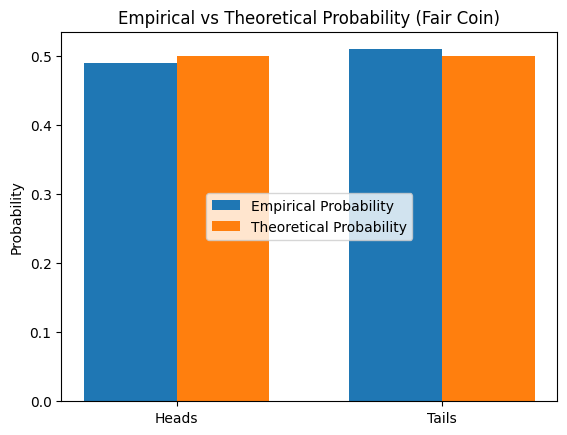

({'Heads': np.float64(0.49), 'Tails': np.float64(0.51)},
 {'Heads': 0.5, 'Tails': 0.5})

In [99]:
total = len(df)

empirical_probs = {
    "Heads": heads_count / total,
    "Tails": tails_count / total
}

# Theoretical probabilities
theoretical_probs = {
    "Heads": 0.5,
    "Tails": 0.5
}

labels = ["Heads", "Tails"]
empirical_values = [empirical_probs["Heads"], empirical_probs["Tails"]]
theoretical_values = [theoretical_probs["Heads"], theoretical_probs["Tails"]]

x = np.arange(len(labels))
width = 0.35

plt.figure()
plt.bar(x - width/2, empirical_values, width, label="Empirical Probability")
plt.bar(x + width/2, theoretical_values, width, label="Theoretical Probability")

plt.xticks(x, labels)
plt.ylabel("Probability")
plt.title("Empirical vs Theoretical Probability (Fair Coin)")
plt.legend(loc="center")
plt.show()

empirical_probs, theoretical_probs

In [101]:

trials = 10000
die1 = np.random.randint(1, 7, trials)
die2 = np.random.randint(1, 7, trials)

sum_dice = die1 + die2

# Empirical probability
empirical_prob = np.sum(sum_dice == 7) / trials

# Theoretical probability
theoretical_prob = 6 / 36

print("Empirical Probability (Sum = 7):", empirical_prob)
print("Theoretical Probability (Sum = 7):", theoretical_prob)


Empirical Probability (Sum = 7): 0.1684
Theoretical Probability (Sum = 7): 0.16666666666666666


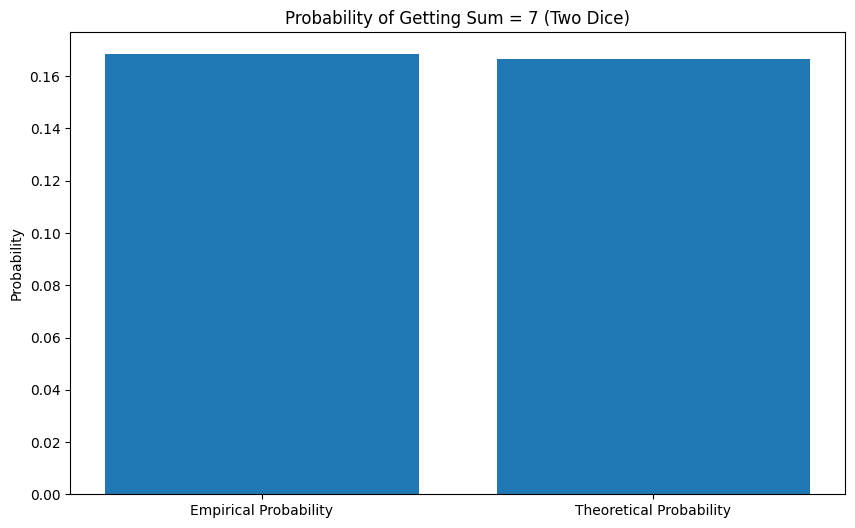